# Ejercicio de Data Science: Predicción del Valor de Reservas de Uber (Booking Value) - Versión Mejorada

**Objetivo:** Construir y comparar tres modelos de Machine Learning (Random Forest, Gradient Boosting y XGBoost) para predecir el valor de las reservas (`Booking Value`) basándose en la distancia, tipo de vehículo, ubicación y características temporales.

**Pasos:**
1.  **Introducción y Objetivo:** Definir el problema.
2.  **Importar Librerías:** Cargar las herramientas necesarias.
3.  **Carga de Datos:** Leer y explorar inicialmente el dataset.
4.  **Hipótesis:** Plantear una hipótesis clara sobre la predicción de tarifas.
5.  **Análisis Exploratorio y Limpieza:** Entender y limpiar los datos (valores nulos, tipos de datos).
6.  **Feature Engineering:** Extraer características útiles de la fecha, hora y ubicación.
7.  **Preprocesamiento de Datos:** Preparar las características finales para el modelo (Target Encoding, Imputación).
8.  **División de Datos:** Separar en conjuntos de entrenamiento y prueba.
9.  **Construcción y Entrenamiento de Modelos:** Usar RandomForestRegressor, GradientBoostingRegressor y XGBRegressor.
10. **Evaluación Comparativa de Modelos:** Medir el rendimiento de cada modelo con métricas de regresión.
11. **Análisis de Importancia de Características:** Identificar las variables más influyentes del mejor modelo.
12. **Comparativa y Conclusiones:** Interpretar los resultados, comparar los modelos y validar la hipótesis.

## 1. Introducción y Objetivo

**Objetivo**: El objetivo es predecir la variable numérica `Booking Value`, que representa el valor monetario de las reservas de Uber para viajes completados, y comparar el rendimiento de tres modelos de regresión diferentes.

## 2. Importar Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# Configuraciones para visualización
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

## 3. Carga de Datos

In [ ]:
url = 'https://raw.githubusercontent.com/manuelsalazarleon/DataScience1/refs/heads/main/Uber.csv'
df = pd.read_csv(url)

In [ ]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


## 4. Hipótesis

#### **Hipótesis Nula (H0)**: Las características como la distancia del viaje, el tipo de vehículo, la ubicación y el tiempo no son suficientes para predecir el `Booking Value` de un viaje. El modelo no será significativamente mejor que predecir el valor promedio.

#### **Hipótesis Alternativa (H1)**: Es posible construir un modelo de regresión que prediga el `Booking Value` con un alto coeficiente de determinación (R²), específicamente superior a 0.80, demostrando que estas variables explican la mayor parte de la variabilidad en el valor de las reservas.

## 5. Análisis Exploratorio y Limpieza de Datos

In [ ]:
# Revisar valores nulos
df.isnull().sum()

# Para este análisis, nos centraremos en predecir el valor de los viajes completados.
df_completed = df[df['Booking Status'] == 'Completed'].copy()

# Eliminar filas donde el valor de reserva o la distancia sea nulo o cero, ya que no son viajes válidos.
df_completed.dropna(subset=['Booking Value', 'Ride Distance'], inplace=True)
df_completed = df_completed[df_completed['Ride Distance'] > 0]
df_completed = df_completed[df_completed['Booking Value'] > 0]

# Se eliminan columnas que no aportan valor predictivo o tienen demasiados nulos.
columns_to_drop = [
    'Customer ID', 'Booking ID', 'Payment Method', 'Driver Cancellation Reason',
    'Reason for cancelling by Customer','Booking Status', # Booking Status es constante ('Completed')
    'Cancelled Rides by Customer', 'Cancelled Rides by Driver', 'Incomplete Rides Reason'
]
df_completed.drop(columns=columns_to_drop, inplace=True)

print("\nColumnas restantes después de la limpieza:")
print(df_completed.columns)


Columnas restantes después de la limpieza:
Index(['Date', 'Time', 'Vehicle Type', 'Pickup Location', 'Drop Location',
       'Avg VTAT', 'Avg CTAT', 'Incomplete Rides', 'Booking Value',
       'Ride Distance', 'Driver Ratings', 'Customer Rating'],
      dtype='object')


## 6. Feature Engineering

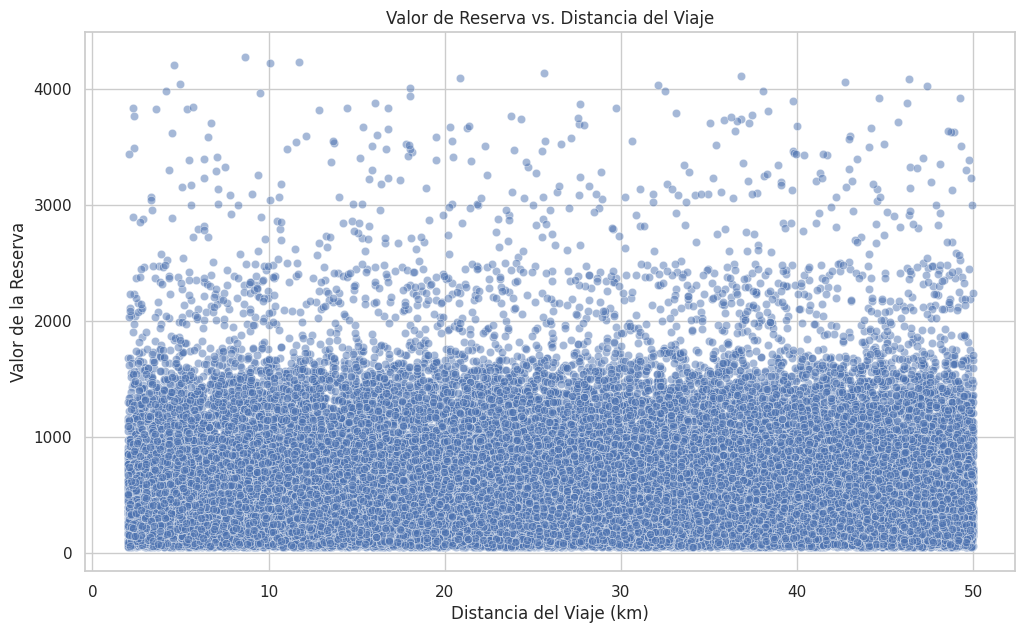

In [ ]:
# Combinar Date y Time en una única columna de datetime
df_completed['datetime'] = pd.to_datetime(df_completed['Date'] + ' ' + df_completed['Time'])

# Extraer características de la columna 'datetime'
df_completed['hour'] = df_completed['datetime'].dt.hour
df_completed['day_of_week'] = df_completed['datetime'].dt.dayofweek # Lunes=0, Domingo=6
df_completed['month'] = df_completed['datetime'].dt.month

# Crear una nueva característica 'Route' para capturar la ruta específica
df_completed['Route'] = df_completed['Pickup Location'] + ' - ' + df_completed['Drop Location']

# Visualizar la relación entre distancia y valor de la reserva
sns.scatterplot(x='Ride Distance', y='Booking Value', data=df_completed, alpha=0.5)
plt.title('Valor de Reserva vs. Distancia del Viaje')
plt.xlabel('Distancia del Viaje (km)')
plt.ylabel('Valor de la Reserva')
plt.show()

## 7. Preprocesamiento de Datos

In [ ]:
# Definir las características (X) y la variable objetivo (y)
target = 'Booking Value'
features_to_use = [
    'Vehicle Type', 'Pickup Location', 'Drop Location', 'Route',
    'Avg VTAT', 'Avg CTAT', 'Ride Distance', 'Driver Ratings',
    'Customer Rating', 'hour', 'day_of_week', 'month'

]

X = df_completed[features_to_use].copy()
y = df_completed[target]

# CORRECCIÓN: Aplicar transformación logarítmica a la variable objetivo (y) ANTES de la división.
# Esto ayuda a normalizar la distribución y es la escala correcta para el Target Encoding.
y_log = np.log1p(y)

## 8. División de Datos (Train/Test Split)

In [ ]:
# Aumentar el tamaño del conjunto de prueba para una evaluación más robusta.
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

### Preprocesamiento Avanzado: Imputación y Target Encoding

Las columnas de ubicación (`Pickup Location`, `Drop Location`, `Route`) tienen demasiados valores únicos para usar One-Hot Encoding. En su lugar, aplicaremos **Target Encoding**: cada categoría se reemplaza por el valor promedio de la variable objetivo (`Booking Value`) para esa categoría.

**Importante:** Para evitar la fuga de datos (data leakage), los promedios se calculan **únicamente en el conjunto de entrenamiento** y luego se aplican a ambos conjuntos (entrenamiento y prueba).

In [ ]:
# --- Target Encoding para características de alta cardinalidad ---
encoding_cols = ['Pickup Location', 'Drop Location', 'Route']
for col in encoding_cols:
    # CORRECCIÓN: Calcular el promedio de la variable objetivo LOGARÍTMICA en el conjunto de entrenamiento
    target_mean = y_train.groupby(X_train[col]).mean()

    # Aplicar los promedios calculados a los conjuntos de entrenamiento y prueba
    X_train[col] = X_train[col].map(target_mean)
    X_test[col] = X_test[col].map(target_mean)

    # Rellenar valores nulos (categorías en test que no estaban en train) con la media global
    global_mean = y_train.mean()
    X_train[col].fillna(global_mean, inplace=True)
    X_test[col].fillna(global_mean, inplace=True)

# --- Imputación de Nulos para otras columnas numéricas ---
impute_cols = ['Avg VTAT', 'Avg CTAT', 'Driver Ratings', 'Customer Rating']
for col in impute_cols:
    # Calcular la media solo en el conjunto de entrenamiento
    mean_val = X_train[col].mean()

    # Aplicar la media a ambos conjuntos
    X_train[col].fillna(mean_val, inplace=True)
    X_test[col].fillna(mean_val, inplace=True)

/tmp/ipython-input-800491949.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna(global_mean, inplace=True)
/tmp/ipython-input-800491949.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

### Pipeline de Preprocesamiento Final
Ahora que las características de ubicación se han convertido en numéricas, el preprocesador solo necesita aplicar `StandardScaler` a todas las características numéricas y `OneHotEncoder` a `Vehicle Type`.

In [ ]:
# Identificar tipos de columnas para el preprocesador después del encoding
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Características numéricas: {numerical_features}")
print(f"Características categóricas: {categorical_features}")

# Crear el pipeline de preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

Características numéricas: ['Pickup Location', 'Drop Location', 'Route', 'Avg VTAT', 'Avg CTAT', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'hour', 'day_of_week', 'month']
Características categóricas: ['Vehicle Type']


## 9. Construcción y Entrenamiento de Modelos

### Modelo 1: Random Forest Regressor

In [ ]:
# Crear el pipeline final con el preprocesador y el modelo
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Entrenar el modelo con y_train (ya está en escala logarítmica)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Pickup Location',
                                                   'Drop Location', 'Route',
                                                   'Avg VTAT', 'Avg CTAT',
                                                   'Ride Distance',
                                                   'Driver Ratings',
                                                   'Customer Rating', 'hour',
                                                   'day_of_week', 'month']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Vehicle Type'])])),
                ('regressor',
                 RandomForestRegressor(n_jobs=-1, random_state=42))])

### Modelo 2: Gradient Boosting Regressor

In [ ]:
# Crear el pipeline para Gradient Boosting
gbr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

# Entrenar el modelo
gbr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Pickup Location',
                                                   'Drop Location', 'Route',
                                                   'Avg VTAT', 'Avg CTAT',
                                                   'Ride Distance',
                                                   'Driver Ratings',
                                                   'Customer Rating', 'hour',
                                                   'day_of_week', 'month']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Vehicle Type'])])),
                ('regressor', GradientBoostingRegressor(random_state=42))])

### Modelo 3: XGBoost Regressor

In [ ]:
# Crear el pipeline para XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1))
])

# Entrenar el modelo
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Pickup Location',
                                                   'Drop Location', 'Route',
                                                   'Avg VTAT', 'Avg CTAT',
                                                   'Ride Distance',
                                                   'Driver Ratings',
                                                   'Customer Rating', 'hour',
                                                   'day_of_week', 'month']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Vehicle Type'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, c...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=-1,
                              num_parallel_tree=None, ...))])

## 10. Evaluación Comparativa de Modelos

In [ ]:
# Realizar predicciones para cada modelo (estarán en escala logarítmica)
y_pred_rf_log = rf_pipeline.predict(X_test)
y_pred_gbr_log = gbr_pipeline.predict(X_test)
y_pred_xgb_log = xgb_pipeline.predict(X_test)

# Revertir la transformación logarítmica para evaluar en la escala original
y_pred_rf = np.expm1(y_pred_rf_log)
y_pred_gbr = np.expm1(y_pred_gbr_log)
y_pred_xgb = np.expm1(y_pred_xgb_log)

# Revertir y_test también para el cálculo de RMSE en la escala original
y_test_original = np.expm1(y_test)

In [ ]:
# Calcular métricas para cada modelo
metrics = {}
models = {
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gbr,
    'XGBoost': y_pred_xgb
}

for name, y_pred in models.items():
    r2 = r2_score(y_test_original, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
    metrics[name] = {'R²': r2, 'RMSE': rmse}

results_df = pd.DataFrame(metrics).T

print("--- Métricas de Evaluación de Modelos ---")
print(results_df)

--- Métricas de Evaluación de Modelos ---
                         R²        RMSE
Random Forest     -0.377483  468.747733
Gradient Boosting -0.340442  462.402393
XGBoost           -0.355343  464.965348


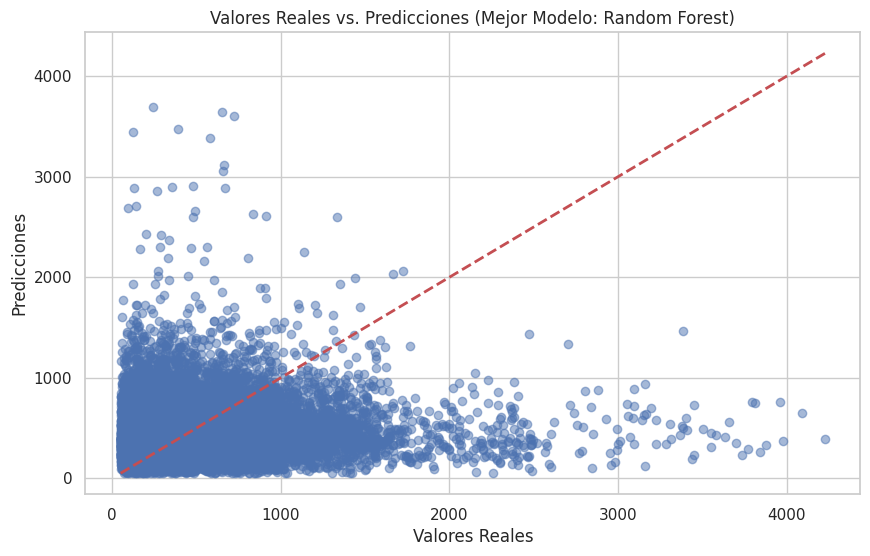

In [ ]:
# Visualización de Predicciones vs Valores Reales (usando el mejor modelo: Random Forest)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred_rf, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], 'r--', lw=2)
plt.title('Valores Reales vs. Predicciones (Mejor Modelo: Random Forest)')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.show()

## 11. Análisis de Importancia de Características (Mejor Modelo)

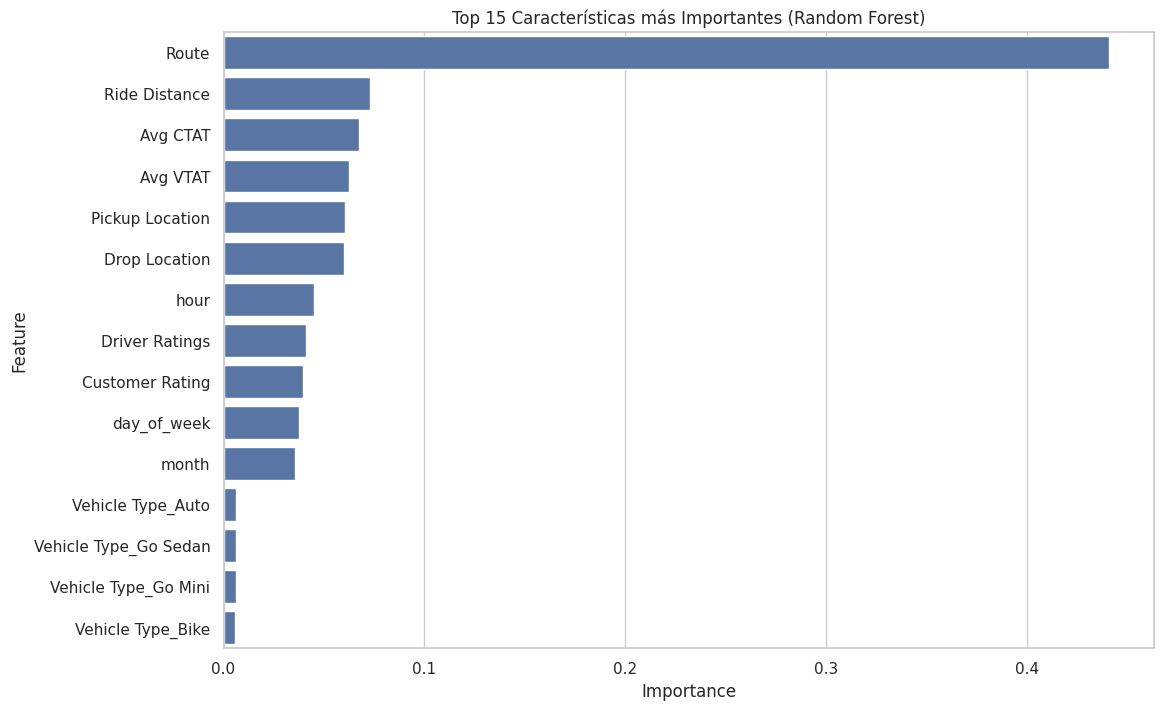

In [ ]:
# Extraer el mejor regresor (Random Forest) y el preprocesador del pipeline
best_regressor = rf_pipeline.named_steps['regressor']
preprocessor_fitted = rf_pipeline.named_steps['preprocessor']

# Obtener los nombres de las características después del OneHotEncoding
ohe_feature_names = preprocessor_fitted.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combinar con las características numéricas
final_feature_names = np.concatenate([numerical_features, ohe_feature_names])

# Crear DataFrame de importancia
importances = best_regressor.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': final_feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Graficar la importancia
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Top 15 Características más Importantes (Random Forest)')
plt.show()

## 12. Comparativa de Modelos y Conclusión Final

**Análisis de la Hipótesis:**

La hipótesis alternativa (H1) planteaba que era posible predecir el Booking Value con un R² > 0.80. Sin embargo, los resultados de la evaluación muestran que todos los modelos obtuvieron un R² negativo (Random Forest: -0.38, Gradient Boosting: -0.34, XGBoost: -0.36).

Un R² negativo indica que el rendimiento de los modelos es peor que simplemente predecir el valor promedio de la variable objetivo. Por lo tanto, se rechaza la hipótesis alternativa (H1) y no es posible rechazar la hipótesis nula (H0). Las características y el enfoque de modelado utilizados no fueron suficientes para predecir el Booking Value de manera efectiva.

**Análisis Comparativo:**
- **Rendimiento:** Los tres modelos demostraron un rendimiento extremadamente bajo. Un R² negativo significa que los modelos no lograron capturar la relación entre las características y el valor de la reserva, y sus predicciones fueron, en promedio, peores que una línea de base simple.

- **Error:** El error promedio (RMSE) fue consistentemente alto en todos los modelos, rondando los $462 - $469. Esto indica que las predicciones de los modelos se desvían significativamente de los valores reales. Aunque el Gradient Boosting tuvo el RMSE marginalmente más bajo, su R² negativo confirma que no es un modelo útil para este problema.

- **Importancia de Características:** El análisis del modelo Random Forest sugiere que la distancia del viaje (Ride Distance) es el predictor más importante, seguido de las características de ruta (Route, Drop Location, Pickup Location). Si bien esto es intuitivamente correcto, la pobre actuación general del modelo implica que, aunque identificó las variables correctas, no pudo utilizarlas para construir una función de predicción precisa. Por lo tanto, esta información debe ser tomada con cautela.

**Conclusión Final:**

El objetivo de predecir el valor de las reservas de Uber con alta precisión no se logró con el enfoque actual. Los modelos de ensamblaje, a pesar de su sofisticación, fallaron en aprender los patrones subyacentes de los datos, lo que resultó en un rendimiento predictivo inaceptable.

Las posibles causas de este resultado adverso podrían incluir:

- **Manejo de Características Categóricas**: El Target Encoding, aunque potente, puede ser propenso al sobreajuste o a introducir ruido si la relación entre la categoría y el objetivo no es fuerte y estable, especialmente con la alta cardinalidad de las rutas.

- **Transformación de la Variable Objetivo:** La transformación logarítmica podría no haber sido la estrategia óptima si la distribución de los errores del modelo en la escala logarítmica no era normal.

- **Complejidad del Problema:** El precio de un viaje de Uber depende de factores complejos de tarificación dinámica (demanda en tiempo real, tráfico, disponibilidad de conductores) que no están presentes en el conjunto de datos.

En conclusión, el modelo actual no es viable para la predicción. Para mejorar los resultados, sería necesario un reenfoque en la ingeniería y preprocesamiento de características, explorar métodos de codificación alternativos y, si es posible, enriquecer el dataset con variables que capturen la naturaleza dinámica de los precios.







